# 🚀 TimeGAN - Forex Synthetic Data Generation

Manuel TensorFlow implementasyonu + Mum Grafikleri

---
⚠️ **GPU'yu aktifleştir:** Runtime > Change runtime type > T4 GPU

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn tensorflow mplfinance -q
print('✅ Kurulum tamamlandı!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 4.1 MB/s eta 0:00:00
✅ Kurulum tamamlandı!


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_no_weekend.csv to cleaned_no_weekend.csv


In [4]:
df = pd.read_csv('cleaned_no_weekend.csv', index_col=0, parse_dates=True)
print(f'Veri boyutu: {df.shape}')
df.head()

Veri boyutu: (99904, 22)


,open,high,low,close,volume,spread,segment_id,logret,hl_range,body,...,sin_hour,cos_hour,sin_dow,cos_dow,atr,realized_vol,rsi,volume_ratio,future_return,direction
2009-10-16 00:00:00,1.49356,1.49402,1.49345,1.49391,704.0,0.0,0,NaN,0.000382,0.000234,...,0.000000,1.000000,-0.433884,-0.900969,0.000382,0.000000,0.000000,1.000000,-0.000502,0.0
2009-10-16 01:00:00,1.49390,1.49564,1.49314,1.49527,1421.0,0.0,0,0.000910,0.001672,0.000916,...,0.258819,0.965926,-0.433884,-0.900969,0.001027,0.000000,0.000000,1.337412,-0.002075,0.0
2009-10-16 02:00:00,1.49524,1.49644,1.49462,1.49641,2180.0,0.0,0,0.000762,0.001216,0.000782,...,0.500000,0.866025,-0.433884,-0.900969,0.001089,0.000105,0.000000,1.519164,-0.003106,0.0
2009-10-16 03:00:00,1.49642,1.49651,1.49479,1.49548,1523.0,0.0,0,-0.000622,0.001150,-0.000629,...,0.707107,0.707107,-0.433884,-0.900969,0.001105,0.000845,0.457726,1.045299,-0.003275,0.0
2009-10-16 04:00:00,1.49543,1.49637,1.49350,1.49395,1659.0,0.0,0,-0.001024,0.001921,-0.000991,...,0.866025,0.500000,-0.433884,-0.900969,0.001269,0.000973,0.008065,1.107920,-0.002473,0.0


In [5]:
FEATURES = [
    'logret', 'hl_range', 'body', 'atr', 'realized_vol',
    'rsi', 'volume_ratio', 'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow'
]

data = df[FEATURES].dropna().values
print(f'Kullanılacak veri: {data.shape}')

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

Kullanılacak veri: (99903, 11)


In [6]:
# Hyperparametreler - OPTİMİZE EDİLDİ
SEQ_LEN = 24
HIDDEN_DIM = 64        # Küçültüldü - daha stabil
NUM_LAYERS = 2
BATCH_SIZE = 256       # Büyütüldü
EPOCHS = 500
NOISE_DIM = 32
N_FEATURES = len(FEATURES)

# Loss ağırlıkları - DÜZENLENDİ
LAMBDA_S = 10          # Supervisor loss weight (100'den düşürüldü)
LAMBDA_V = 10          # Moment loss weight (100'den düşürüldü)

In [7]:
def create_sequences(data, seq_len):
    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i:i+seq_len])
    return np.array(sequences)

sequences = create_sequences(data_scaled, SEQ_LEN)
print(f'Sequences: {sequences.shape}')

Sequences: (99879, 24, 11)


## TimeGAN Model Tanımları (Optimize Edilmiş)

In [8]:
def make_embedder():
    model = keras.Sequential([
        layers.InputLayer(input_shape=(SEQ_LEN, N_FEATURES)),
        layers.GRU(HIDDEN_DIM, return_sequences=True, dropout=0.1),
        layers.GRU(HIDDEN_DIM, return_sequences=True, dropout=0.1),
        layers.TimeDistributed(layers.Dense(HIDDEN_DIM, activation='sigmoid'))
    ], name='embedder')
    return model

def make_recovery():
    model = keras.Sequential([
        layers.InputLayer(input_shape=(SEQ_LEN, HIDDEN_DIM)),
        layers.GRU(HIDDEN_DIM, return_sequences=True, dropout=0.1),
        layers.GRU(HIDDEN_DIM, return_sequences=True, dropout=0.1),
        layers.TimeDistributed(layers.Dense(N_FEATURES, activation='sigmoid'))
    ], name='recovery')
    return model

def make_generator():
    model = keras.Sequential([
        layers.InputLayer(input_shape=(SEQ_LEN, NOISE_DIM)),
        layers.GRU(HIDDEN_DIM, return_sequences=True, dropout=0.1),
        layers.GRU(HIDDEN_DIM, return_sequences=True, dropout=0.1),
        layers.TimeDistributed(layers.Dense(HIDDEN_DIM, activation='sigmoid'))
    ], name='generator')
    return model

def make_supervisor():
    model = keras.Sequential([
        layers.InputLayer(input_shape=(SEQ_LEN, HIDDEN_DIM)),
        layers.GRU(HIDDEN_DIM, return_sequences=True, dropout=0.1),
        layers.TimeDistributed(layers.Dense(HIDDEN_DIM, activation='sigmoid'))
    ], name='supervisor')
    return model

def make_discriminator():
    model = keras.Sequential([
        layers.InputLayer(input_shape=(SEQ_LEN, HIDDEN_DIM)),
        layers.GRU(HIDDEN_DIM, return_sequences=True, dropout=0.1),
        layers.GRU(HIDDEN_DIM, dropout=0.1),
        layers.Dense(1)
    ], name='discriminator')
    return model

In [9]:
embedder = make_embedder()
recovery = make_recovery()
generator = make_generator()
supervisor = make_supervisor()
discriminator = make_discriminator()

# Optimizer'lar - Düzenlendi
autoencoder_opt = keras.optimizers.Adam(5e-4)
supervisor_opt = keras.optimizers.Adam(5e-4)
generator_opt = keras.optimizers.Adam(1e-4)      # Düşürüldü
discriminator_opt = keras.optimizers.Adam(1e-4)

print('✅ Modeller oluşturuldu!')

✅ Modeller oluşturuldu!


## Eğitim Fonksiyonları (Optimize Edilmiş)

In [10]:
mse = keras.losses.MeanSquaredError()
bce = keras.losses.BinaryCrossentropy(from_logits=True)

@tf.function
def train_autoencoder_step(x):
    with tf.GradientTape() as tape:
        h = embedder(x, training=True)
        x_tilde = recovery(h, training=True)
        loss = mse(x, x_tilde)

    grads = tape.gradient(loss, embedder.trainable_variables + recovery.trainable_variables)
    autoencoder_opt.apply_gradients(zip(grads, embedder.trainable_variables + recovery.trainable_variables))
    return loss

@tf.function
def train_supervisor_step(x):
    with tf.GradientTape() as tape:
        h = embedder(x, training=False)
        h_hat = supervisor(h, training=True)
        loss = mse(h[:, 1:, :], h_hat[:, :-1, :])

    grads = tape.gradient(loss, supervisor.trainable_variables)
    supervisor_opt.apply_gradients(zip(grads, supervisor.trainable_variables))
    return loss

@tf.function
def train_generator_step(x, z):
    with tf.GradientTape() as tape:
        h = embedder(x, training=False)
        e_hat = generator(z, training=True)
        h_hat = supervisor(e_hat, training=True)

        # Discriminator output
        y_fake = discriminator(h_hat, training=False)
        y_fake_e = discriminator(e_hat, training=False)

        # 1. Adversarial loss - gerçekmiş gibi davran
        g_loss_u = bce(tf.ones_like(y_fake), y_fake)
        g_loss_u_e = bce(tf.ones_like(y_fake_e), y_fake_e)

        # 2. Supervised loss - temporal dynamics
        g_loss_s = mse(h[:, 1:, :], h_hat[:, :-1, :])

        # 3. Moment matching loss (mean + std)
        x_hat = recovery(h_hat, training=False)
        g_loss_v1 = tf.reduce_mean(tf.abs(tf.reduce_mean(x_hat, axis=0) - tf.reduce_mean(x, axis=0)))
        g_loss_v2 = tf.reduce_mean(tf.abs(tf.math.reduce_std(x_hat, axis=0) - tf.math.reduce_std(x, axis=0)))
        g_loss_v = g_loss_v1 + g_loss_v2

        # Toplam loss - AĞIRLIKLAR DÜZENLENDİ
        g_loss = g_loss_u + g_loss_u_e + LAMBDA_S * g_loss_s + LAMBDA_V * g_loss_v

    grads = tape.gradient(g_loss, generator.trainable_variables + supervisor.trainable_variables)
    generator_opt.apply_gradients(zip(grads, generator.trainable_variables + supervisor.trainable_variables))

    return g_loss, g_loss_u, g_loss_s, g_loss_v

@tf.function
def train_discriminator_step(x, z):
    with tf.GradientTape() as tape:
        h = embedder(x, training=False)
        e_hat = generator(z, training=False)
        h_hat = supervisor(e_hat, training=False)

        y_real = discriminator(h, training=True)
        y_fake = discriminator(h_hat, training=True)
        y_fake_e = discriminator(e_hat, training=True)

        d_loss_real = bce(tf.ones_like(y_real), y_real)
        d_loss_fake = bce(tf.zeros_like(y_fake), y_fake)
        d_loss_fake_e = bce(tf.zeros_like(y_fake_e), y_fake_e)
        d_loss = d_loss_real + d_loss_fake + d_loss_fake_e

    # Sadece discriminator çok iyi değilse güncelle (label smoothing etkisi)
    if d_loss > 0.15:
        grads = tape.gradient(d_loss, discriminator.trainable_variables)
        discriminator_opt.apply_gradients(zip(grads, discriminator.trainable_variables))

    return d_loss

In [11]:
dataset = tf.data.Dataset.from_tensor_slices(sequences.astype('float32'))
dataset = dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
print(f'Dataset hazır! Batch sayısı: {len(dataset)}')

Dataset hazır! Batch sayısı: 391


In [12]:
# Phase 1: Autoencoder
print('📍 Phase 1: Autoencoder Eğitimi')
for epoch in range(EPOCHS // 5):
    losses = []
    for batch in dataset:
        loss = train_autoencoder_step(batch)
        losses.append(loss.numpy())
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS//5} - Loss: {np.mean(losses):.6f}')
print('✅ Phase 1 tamamlandı!')

📍 Phase 1: Autoencoder Eğitimi
Epoch 20/100 - Loss: 0.002914
Epoch 40/100 - Loss: 0.002246
Epoch 60/100 - Loss: 0.002013
Epoch 80/100 - Loss: 0.001825
Epoch 100/100 - Loss: 0.001757
✅ Phase 1 tamamlandı!


In [13]:
# Phase 2: Supervisor
print('📍 Phase 2: Supervisor Eğitimi')
for epoch in range(EPOCHS // 5):
    losses = []
    for batch in dataset:
        loss = train_supervisor_step(batch)
        losses.append(loss.numpy())
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS//5} - Loss: {np.mean(losses):.6f}')
print('✅ Phase 2 tamamlandı!')

📍 Phase 2: Supervisor Eğitimi
Epoch 20/100 - Loss: 0.002661
Epoch 40/100 - Loss: 0.002373
Epoch 60/100 - Loss: 0.002292
Epoch 80/100 - Loss: 0.002242
Epoch 100/100 - Loss: 0.002216
✅ Phase 2 tamamlandı!


In [14]:
# Phase 3: Joint Training - OPTİMİZE EDİLDİ
print('📍 Phase 3: Joint Eğitim (GAN)')

# Loss geçmişi
history = {'g_loss': [], 'd_loss': [], 'g_loss_u': [], 'g_loss_s': [], 'g_loss_v': []}

for epoch in range(EPOCHS):
    g_losses, d_losses = [], []
    g_u_losses, g_s_losses, g_v_losses = [], [], []

    for batch in dataset:
        z = tf.random.uniform((batch.shape[0], SEQ_LEN, NOISE_DIM), 0, 1)

        # Generator eğit (1 adım)
        g_loss, g_u, g_s, g_v = train_generator_step(batch, z)

        # Discriminator eğit (1 adım)
        d_loss = train_discriminator_step(batch, z)

        g_losses.append(g_loss.numpy())
        d_losses.append(d_loss.numpy())
        g_u_losses.append(g_u.numpy())
        g_s_losses.append(g_s.numpy())
        g_v_losses.append(g_v.numpy())

    # Geçmişe kaydet
    history['g_loss'].append(np.mean(g_losses))
    history['d_loss'].append(np.mean(d_losses))
    history['g_loss_u'].append(np.mean(g_u_losses))
    history['g_loss_s'].append(np.mean(g_s_losses))
    history['g_loss_v'].append(np.mean(g_v_losses))

    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS}')
        print(f'  G_Total: {np.mean(g_losses):.4f} | G_Adv: {np.mean(g_u_losses):.4f} | G_Sup: {np.mean(g_s_losses):.4f} | G_Mom: {np.mean(g_v_losses):.4f}')
        print(f'  D_Loss: {np.mean(d_losses):.4f}')

print('✅ Phase 3 tamamlandı!')

📍 Phase 3: Joint Eğitim (GAN)
Epoch 50/500
  G_Total: 10.4493 | G_Adv: 2.7372 | G_Sup: 0.0944 | G_Mom: 0.1297
  D_Loss: 0.1860
Epoch 100/500
  G_Total: 6.9693 | G_Adv: 2.1592 | G_Sup: 0.0706 | G_Mom: 0.0752
  D_Loss: 0.5740
Epoch 150/500
  G_Total: 5.2072 | G_Adv: 1.7386 | G_Sup: 0.0664 | G_Mom: 0.0598
  D_Loss: 0.9164
Epoch 200/500
  G_Total: 4.4130 | G_Adv: 1.2252 | G_Sup: 0.0672 | G_Mom: 0.0481
  D_Loss: 0.8733
Epoch 250/500
  G_Total: 4.2725 | G_Adv: 1.2584 | G_Sup: 0.0676 | G_Mom: 0.0426
  D_Loss: 0.8579
Epoch 300/500
  G_Total: 3.8201 | G_Adv: 0.9433 | G_Sup: 0.0647 | G_Mom: 0.0366
  D_Loss: 0.8558
Epoch 350/500
  G_Total: 3.6969 | G_Adv: 0.7639 | G_Sup: 0.0641 | G_Mom: 0.0384
  D_Loss: 0.8283
Epoch 400/500
  G_Total: 4.1764 | G_Adv: 1.1120 | G_Sup: 0.0637 | G_Mom: 0.0363
  D_Loss: 0.8717
Epoch 450/500
  G_Total: 4.2958 | G_Adv: 1.1334 | G_Sup: 0.0630 | G_Mom: 0.0347
  D_Loss: 0.8284
Epoch 500/500
  G_Total: 4.8918 | G_Adv: 1.3318 | G_Sup: 0.0646 | G_Mom: 0.0392
  D_Loss: 0.7082


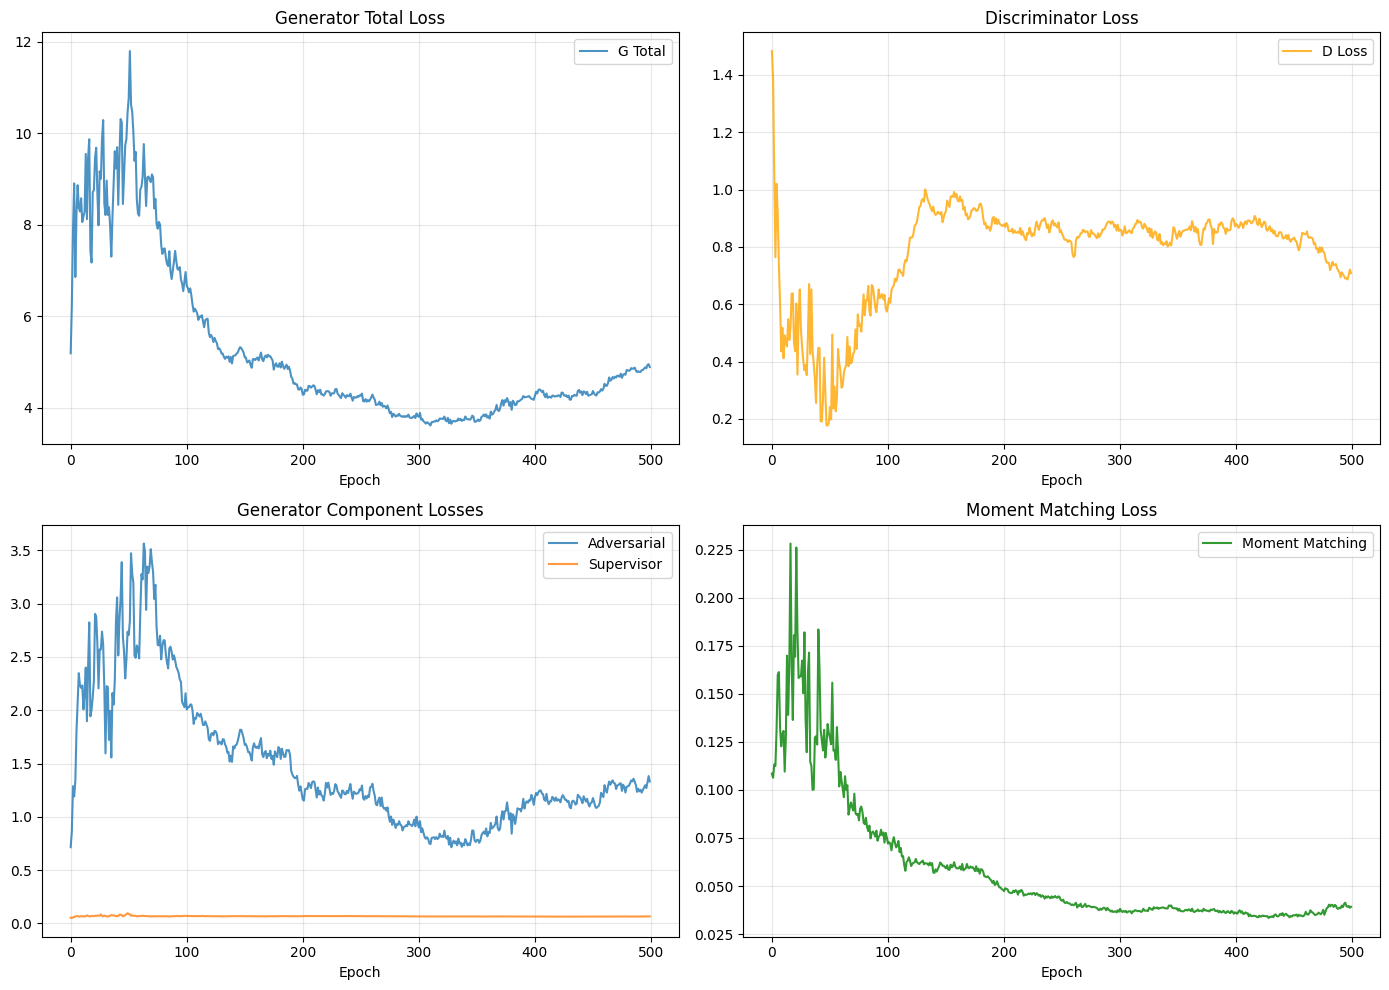

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# Eğitim grafiği
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(history['g_loss'], label='G Total', alpha=0.8)
axes[0,0].set_title('Generator Total Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(history['d_loss'], label='D Loss', color='orange', alpha=0.8)
axes[0,1].set_title('Discriminator Loss')
axes[0,1].set_xlabel('Epoch')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(history['g_loss_u'], label='Adversarial', alpha=0.8)
axes[1,0].plot(history['g_loss_s'], label='Supervisor', alpha=0.8)
axes[1,0].set_title('Generator Component Losses')
axes[1,0].set_xlabel('Epoch')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(history['g_loss_v'], label='Moment Matching', color='green', alpha=0.8)
axes[1,1].set_title('Moment Matching Loss')
axes[1,1].set_xlabel('Epoch')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()
files.download('training_history.png')

In [16]:
# Modelleri kaydet
embedder.save('timegan_embedder.keras')
recovery.save('timegan_recovery.keras')
generator.save('timegan_generator.keras')
supervisor.save('timegan_supervisor.keras')
print('✅ Modeller kaydedildi!')

✅ Modeller kaydedildi!


## Sentetik Veri Üret

In [17]:
def generate_synthetic_data(n_samples):
    z = tf.random.uniform((n_samples, SEQ_LEN, NOISE_DIM), 0, 1)
    e_hat = generator(z, training=False)
    h_hat = supervisor(e_hat, training=False)
    x_hat = recovery(h_hat, training=False)
    return x_hat.numpy()

n_samples = 1000
synthetic_sequences = generate_synthetic_data(n_samples)
print(f'Sentetik veri: {synthetic_sequences.shape}')

synthetic_flat = synthetic_sequences.reshape(-1, N_FEATURES)
synthetic_original = scaler.inverse_transform(synthetic_flat)
df_synthetic = pd.DataFrame(synthetic_original, columns=FEATURES)

Sentetik veri: (1000, 24, 11)


## 📊 Dağılım Karşılaştırma

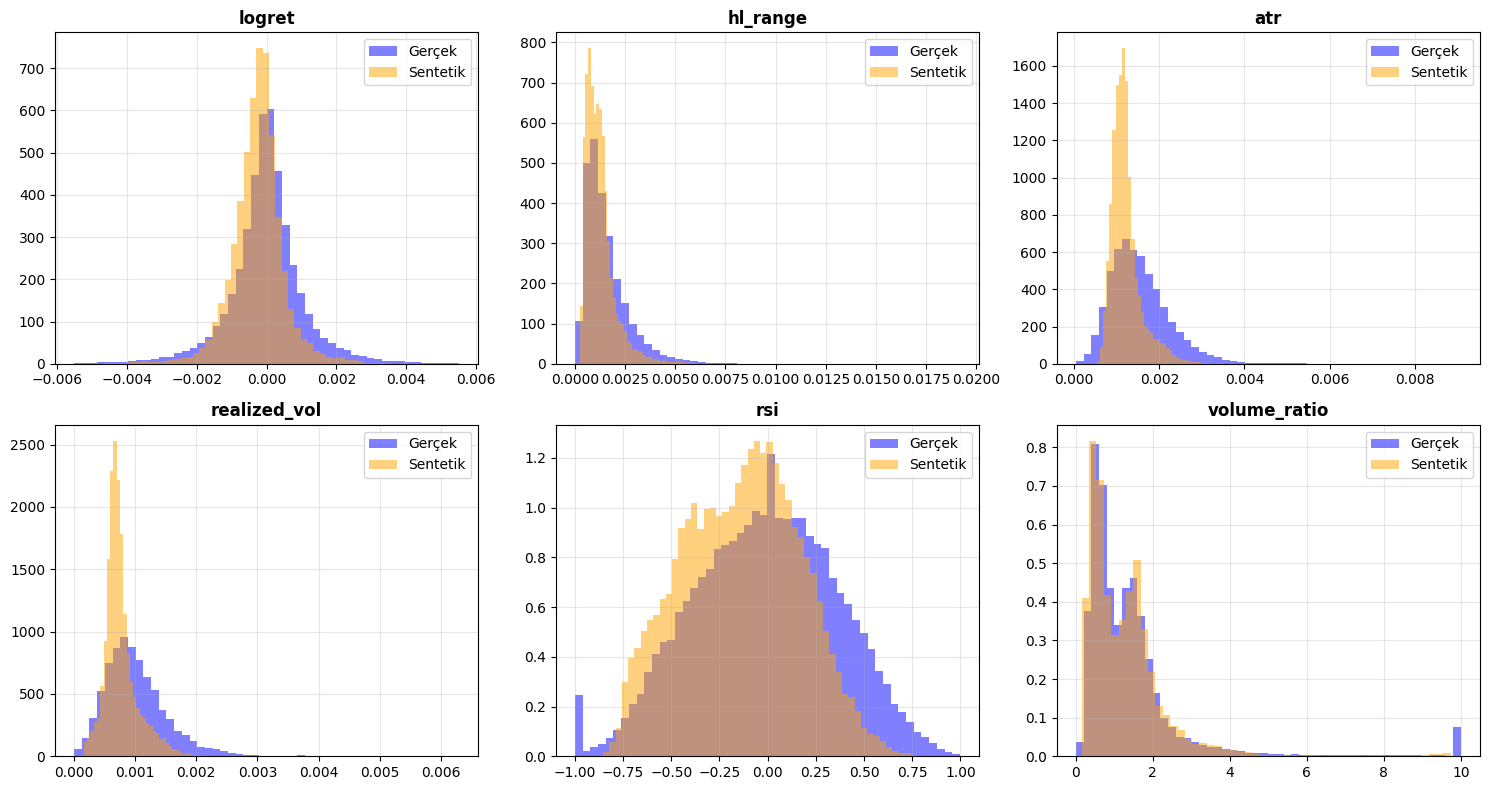

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features_to_plot = ['logret', 'hl_range', 'atr', 'realized_vol', 'rsi', 'volume_ratio']

for i, feat in enumerate(features_to_plot):
    ax = axes[i//3, i%3]
    ax.hist(df[feat].dropna().values[:50000], bins=50, alpha=0.5, label='Gerçek', density=True, color='blue')
    ax.hist(df_synthetic[feat].values, bins=50, alpha=0.5, label='Sentetik', density=True, color='orange')
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distribution_comparison.png', dpi=150)
plt.show()
files.download('distribution_comparison.png')

## 🕯️ MUM GRAFİKLERİ KARŞILAŞTIRMA

In [19]:
# Gerçek OHLC verisi (ilk 100 mum)
df_real_ohlc = df[['open', 'high', 'low', 'close', 'volume']].dropna().head(100).copy()
df_real_ohlc.columns = ['Open', 'High', 'Low', 'Close', 'Volume']
df_real_ohlc.index = pd.to_datetime(df_real_ohlc.index)

print('Gerçek veri örneği:')
df_real_ohlc.head()

Gerçek veri örneği:


,Open,High,Low,Close,Volume
2009-10-16 00:00:00,1.49356,1.49402,1.49345,1.49391,704.0
2009-10-16 01:00:00,1.49390,1.49564,1.49314,1.49527,1421.0
2009-10-16 02:00:00,1.49524,1.49644,1.49462,1.49641,2180.0
2009-10-16 03:00:00,1.49642,1.49651,1.49479,1.49548,1523.0
2009-10-16 04:00:00,1.49543,1.49637,1.49350,1.49395,1659.0


In [20]:
# Sentetik veriden OHLC oluştur
# logret ve body'den fiyat serisi reconstruct et

def reconstruct_ohlc(synthetic_df, start_price=1.0):
    """Sentetik log return'lerden OHLC verisini yeniden oluştur"""
    n = len(synthetic_df)

    # Close fiyatları (log return'den)
    closes = [start_price]
    for i in range(1, n):
        logret = synthetic_df['logret'].iloc[i]
        closes.append(closes[-1] * np.exp(logret))
    closes = np.array(closes[:n])

    # Open fiyatları (body'den)
    opens = closes - synthetic_df['body'].values * closes

    # High/Low (hl_range'den)
    hl_ranges = synthetic_df['hl_range'].values * closes
    highs = np.maximum(opens, closes) + hl_ranges * 0.3
    lows = np.minimum(opens, closes) - hl_ranges * 0.3

    # Volume (normalized'dan geri)
    volumes = np.abs(synthetic_df['volume_ratio'].values * 2000 + 1000)

    return pd.DataFrame({
        'Open': opens,
        'High': highs,
        'Low': lows,
        'Close': closes,
        'Volume': volumes
    })

# İlk 100 sentetik mumu oluştur
df_synth_ohlc = reconstruct_ohlc(df_synthetic.head(100), start_price=df_real_ohlc['Close'].iloc[0])
df_synth_ohlc.index = pd.date_range(start='2024-01-01', periods=100, freq='1h')

print('Sentetik OHLC örneği:')
df_synth_ohlc.head()

Sentetik OHLC örneği:


,Open,High,Low,Close,Volume
2024-01-01 00:00:00,1.492892,1.494825,1.491977,1.493910,4849.555664
2024-01-01 01:00:00,1.493956,1.494736,1.491075,1.491856,3587.018066
2024-01-01 02:00:00,1.491873,1.492287,1.491357,1.491771,2667.527344
2024-01-01 03:00:00,1.491762,1.492507,1.491476,1.492221,2251.915039
2024-01-01 04:00:00,1.492253,1.492950,1.489622,1.490319,2633.450195


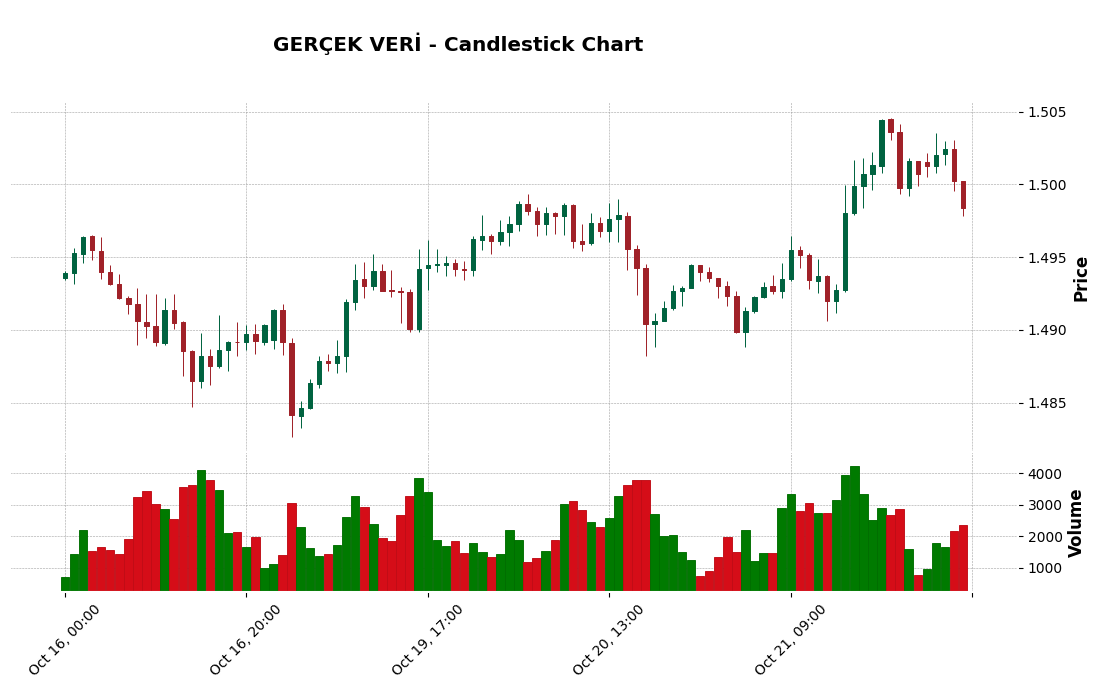

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# Mum grafikleri - GERÇEK
fig1, ax1 = mpf.plot(
    df_real_ohlc,
    type='candle',
    style='charles',
    title='\nGERÇEK VERİ - Candlestick Chart',
    volume=True,
    figsize=(14, 7),
    returnfig=True
)
fig1.savefig('candlestick_real.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('candlestick_real.png')

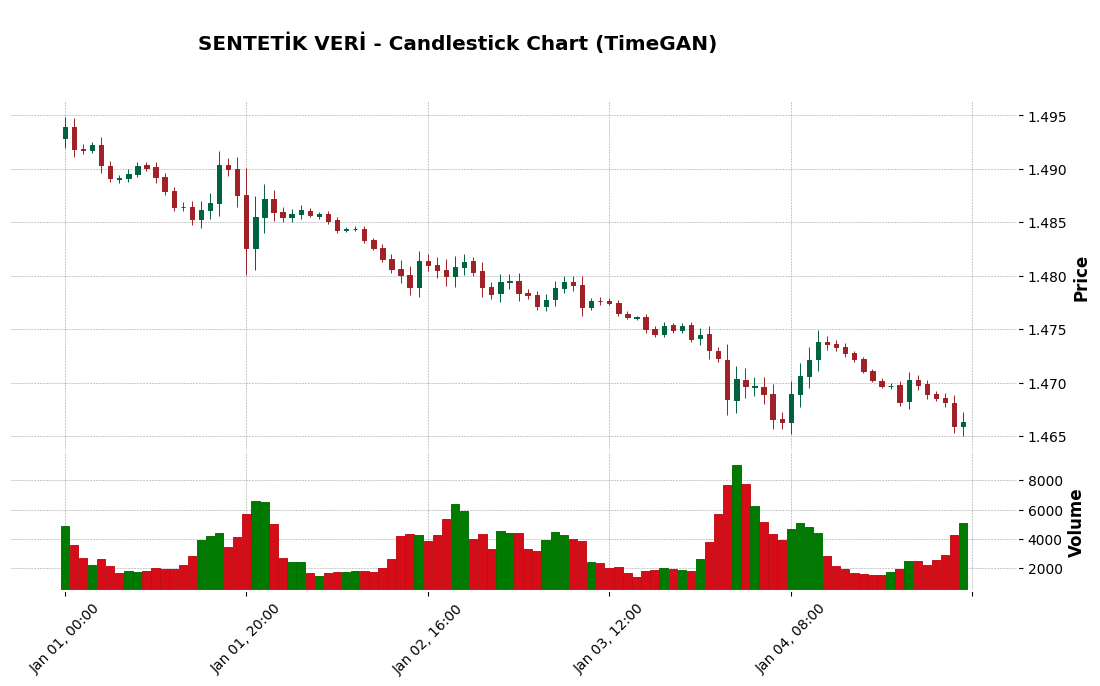

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
# Mum grafikleri - SENTETİK
fig2, ax2 = mpf.plot(
    df_synth_ohlc,
    type='candle',
    style='charles',
    title='\nSENTETİK VERİ - Candlestick Chart (TimeGAN)',
    volume=True,
    figsize=(14, 7),
    returnfig=True
)
fig2.savefig('candlestick_synthetic.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('candlestick_synthetic.png')

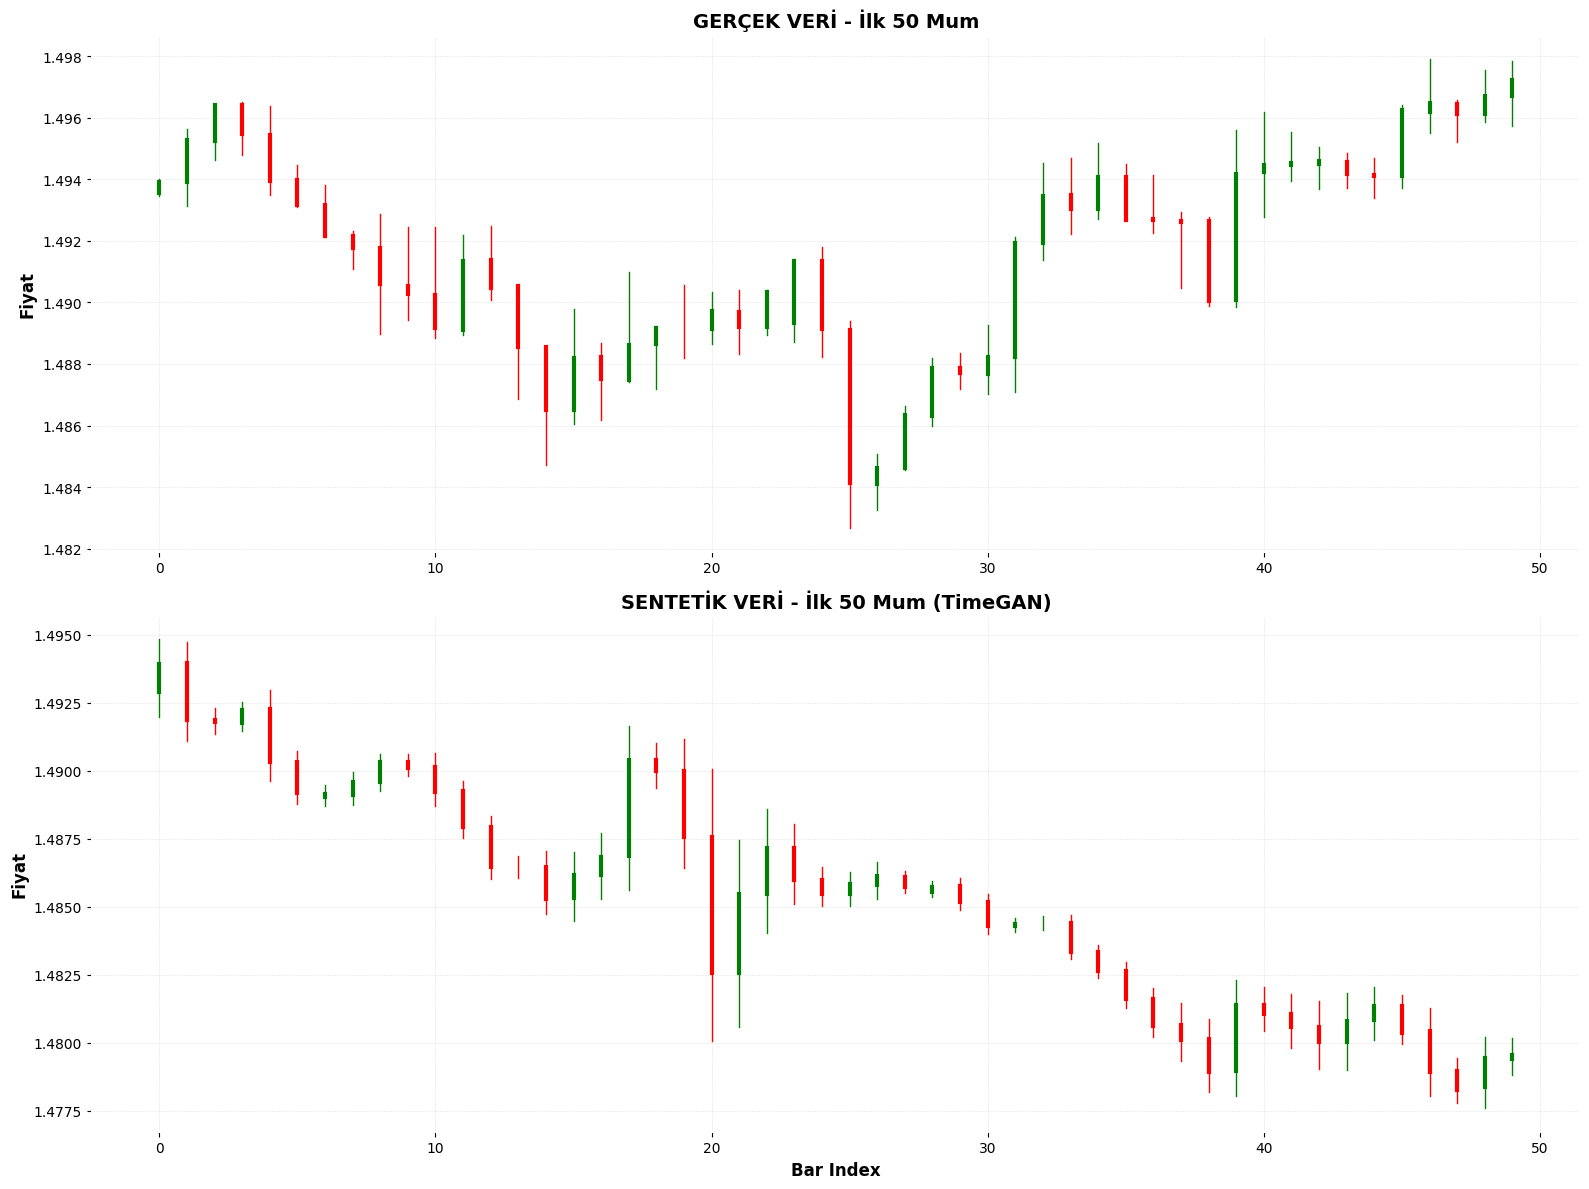

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# Yan yana karşılaştırma
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Gerçek
ax1 = axes[0]
for i in range(min(50, len(df_real_ohlc))):
    row = df_real_ohlc.iloc[i]
    color = 'green' if row['Close'] >= row['Open'] else 'red'
    ax1.plot([i, i], [row['Low'], row['High']], color=color, linewidth=1)
    ax1.plot([i, i], [row['Open'], row['Close']], color=color, linewidth=3)
ax1.set_title('GERÇEK VERİ - İlk 50 Mum', fontsize=14, fontweight='bold')
ax1.set_ylabel('Fiyat')
ax1.grid(True, alpha=0.3)

# Sentetik
ax2 = axes[1]
for i in range(min(50, len(df_synth_ohlc))):
    row = df_synth_ohlc.iloc[i]
    color = 'green' if row['Close'] >= row['Open'] else 'red'
    ax2.plot([i, i], [row['Low'], row['High']], color=color, linewidth=1)
    ax2.plot([i, i], [row['Open'], row['Close']], color=color, linewidth=3)
ax2.set_title('SENTETİK VERİ - İlk 50 Mum (TimeGAN)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Fiyat')
ax2.set_xlabel('Bar Index')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('candlestick_comparison.png', dpi=150)
plt.show()
files.download('candlestick_comparison.png')

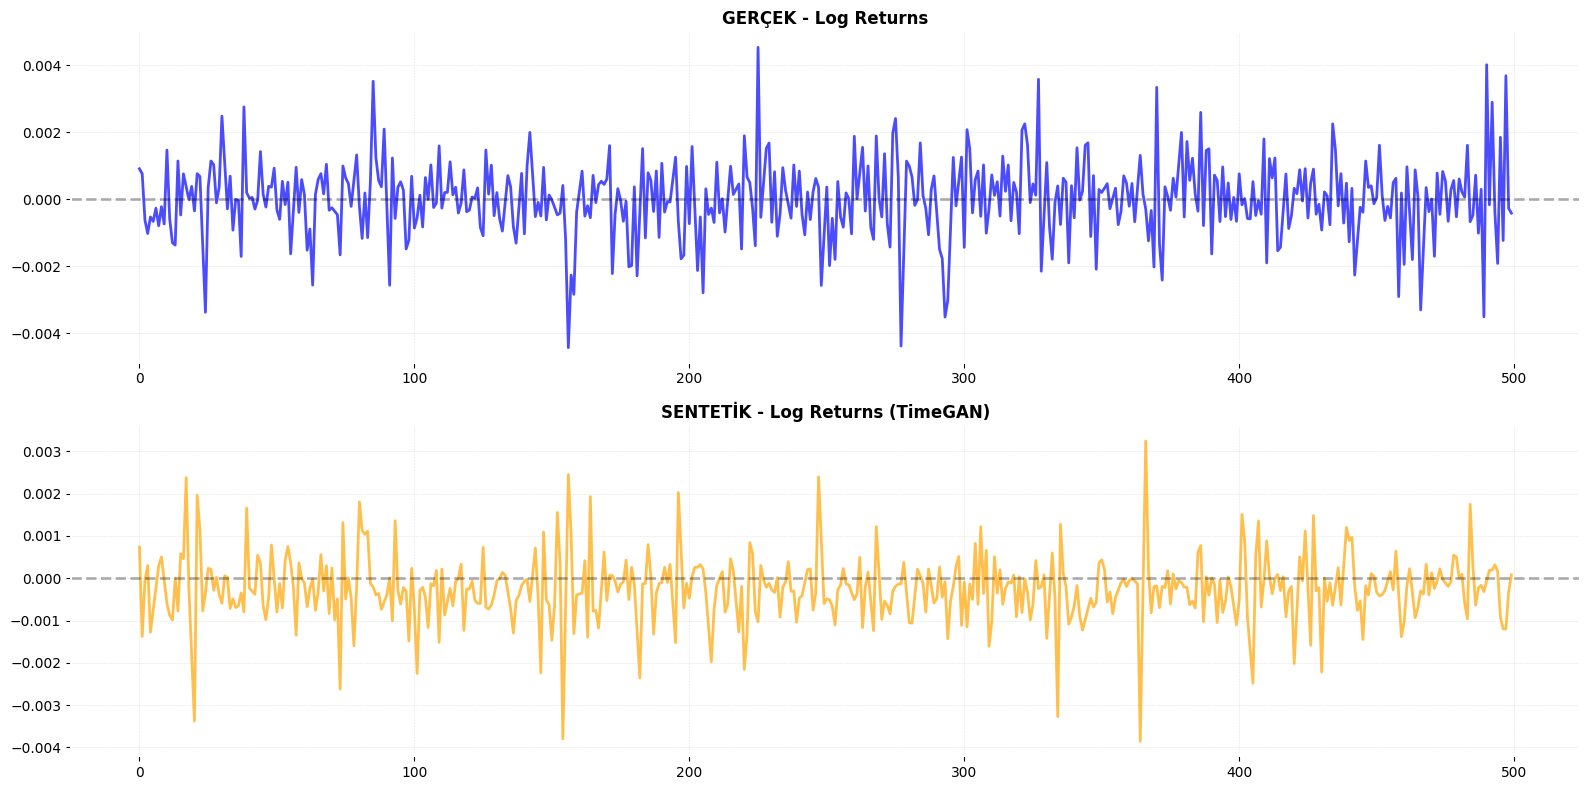

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# Log return zaman serisi karşılaştırma
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(df['logret'].dropna().values[:500], alpha=0.7, color='blue')
axes[0].set_title('GERÇEK - Log Returns', fontsize=12, fontweight='bold')
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_synthetic['logret'].values[:500], alpha=0.7, color='orange')
axes[1].set_title('SENTETİK - Log Returns (TimeGAN)', fontsize=12, fontweight='bold')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('logret_timeseries.png', dpi=150)
plt.show()
files.download('logret_timeseries.png')

In [25]:
# Kaydet
df_synthetic.to_csv('synthetic_forex_timegan.csv', index=False)
df_synth_ohlc.to_csv('synthetic_ohlc_timegan.csv')

files.download('synthetic_forex_timegan.csv')
files.download('synthetic_ohlc_timegan.csv')
print('✅ Tüm dosyalar indirildi!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Tüm dosyalar indirildi!


---
## 🎉 Tebrikler!

**İyileştirmeler için Pro+ önerileri:**
- `EPOCHS = 1000+`
- `SEQ_LEN = 48` (2 gün)
- `HIDDEN_DIM = 128`
- `LAMBDA_S, LAMBDA_V = 5` (daha da düşür eğer G_loss yüksekse)